## Use a trained segmentation model and apply it to new images ##

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import json
import time
import glob
import random
from pathlib import Path

from matplotlib import pyplot as plt
from matplotlib.pyplot import cm
from matplotlib import patches

# Appearance of the Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
np.set_printoptions(linewidth=110)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# PyTorch libraries
import torch

# Detectron2 library
import detectron2
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog, build_detection_test_loader
from detectron2.evaluation import COCOEvaluator, inference_on_dataset

# Import this module with autoreload
%load_ext autoreload
%autoreload 2
import computervision as dm
from computervision.imageproc import ImageData, transform_box, plot_boxes, crop_image
from computervision.fileutils import FileOP
from computervision.inference import get_gpu_info

print(f'Project module version: {dm.__version__}')
print(f'Detectron2 version:     {detectron2.__version__}')

/usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Project module version: v0.0.2
Detectron2 version:     0.6


In [2]:
# GPU checks
device, device_str = get_gpu_info()
print()
print(f'Device for model training/inference: {device}')

CUDA available: True
Number of GPUs found:  1
Current device ID: 0
GPU device name:   NVIDIA GeForce RTX 3060 Laptop GPU
PyTorch version:   2.8.0a0+34c6371d24.nv25.08
CUDA version:      13.0
CUDNN version:     91200
Current device:    cuda:0

Device for model training/inference: cuda:0


In [3]:
# Path settings 
# Main data directory (defined as environment variable in docker-compose.yml)
data_root = os.environ.get('DATA_DIR')

# Download directory (change as needed)
dentex_dir = os.path.join(data_root, 'dentex')
model_dir = os.path.join(data_root, 'model')
data_dir = os.path.join(dentex_dir, 'dentex_detection')

# This image directory is where the xrays are in the archive, so should be left as-is
image_dir = os.path.join(data_dir, 'quadrant_enumeration', 'xrays')

# Directory for the output
output_dir = os.path.join(data_dir, 'output')
output_dir_predictions = os.path.join(output_dir, 'segm_predictions')
Path(output_dir_predictions).mkdir(parents=True, exist_ok=True)

# Data frame with data splits 
data_df_file_name = 'dentex_detection_datasplit.parquet'
data_df_file = os.path.join(data_dir, data_df_file_name)

# Annotation file for testdata
test_annotation_file_name = 'dentex_detection_test.json'
test_annotation_file = os.path.join(data_dir, test_annotation_file_name)

### Register the test dataset ####

In [4]:
with open(test_annotation_file, 'r') as fl:
    annotations = json.load(fl)
dataset_name = 'dentex_test'
annotations_dict = {dataset_name: annotations}
if dataset_name not in DatasetCatalog:
    DatasetCatalog.register(name=dataset_name, func=lambda d=dataset_name: annotations_dict.get(d))
    MetadataCatalog.get(dataset_name).set(thing_classes=['tooth'])

### Detectron2 performance testing ###

In [5]:
# Let's see if we have a saved checkpoint. If not, use this one:
link = 'https://dsets.s3.amazonaws.com/dentex/toothsegmentation_1K.pth'

# The previous training notebook should have the defined model name
model_name = 'Toothsegment'
model_version = 1

# The latest checkpoint should be here
checkpoint_dir = os.path.join(model_dir, 
                              model_name,
                              f'version_{model_version}')

last_checkpoint_name = 'model_final_do_not_find_this.pth'
last_checkpoint = glob.glob(os.path.join(checkpoint_dir, last_checkpoint_name))
if len(last_checkpoint) > 0:
    print(f'Using checkpoint file "{last_checkpoint_name}" in {checkpoint_dir}.')
    checkpoint_file = last_checkpoint[0]
else:
    print(f'Last checkpoint file "{last_checkpoint_name}" not found in {checkpoint_dir}.')
    print(f'Downloading checkpoint from {link}')
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    checkpoint_file = FileOP().download_from_url(url=link, download_dir=checkpoint_dir)

Last checkpoint file "model_final_do_not_find_this.pth" not found in /app/data/model/Toothsegment/version_1.
Created .pth file.


In [6]:
output_dir = os.path.join(model_dir, model_name, f'version_{model_version}')

# Load the config file. This was created right before training the model.
model_config_file_name = f'{model_name}_{model_version}_config.yml'
model_config_file = os.path.join(output_dir, model_config_file_name)

# Recreate the model configuration
cfg = get_cfg()
cfg.merge_from_file(model_config_file)
cfg.MODEL.DEVICE = device.type
cfg.MODEL.WEIGHTS = checkpoint_file

# Set the score threshold
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5

# Create the dentex predictor instance
predictor = DefaultPredictor(cfg)
val_loader = build_detection_test_loader(cfg, 'dentex_test')

# Create COCO-Evaluator for the test set
evaluator = COCOEvaluator(dataset_name='dentex_test', 
                          tasks=('bbox', 'segm', ), 
                          distributed=False, 
                          output_dir=output_dir)

# Run model evaluation on test set
results = inference_on_dataset(predictor.model, val_loader, evaluator)

# Combine test results on bounding boxes and segmentations into one table
results_df_list = []
for task in ['bbox', 'segm']:
    results_df_task = pd.DataFrame(results.get(task), index=[0]).\
                    assign(checkpoint=os.path.basename(checkpoint_file),
                           task=task)
    results_df_list.append(results_df_task)
results_df = pd.concat(results_df_list, axis=0, ignore_index=True)
print()
display(results_df)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.532
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.960
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.510
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.519
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.532
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.023
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.232
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.606
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.521
 Average Recall     (AR) @[ IoU=0.50:

,AP,AP50,AP75,APs,APm,APl,checkpoint,task
0,53.158715,95.960175,51.017931,NaN,51.914191,53.238746,toothsegmentation_1K.pth,bbox
1,51.401499,95.944669,50.280192,NaN,43.900973,51.417489,toothsegmentation_1K.pth,segm


### Example predictions on the test images ###

In [7]:
files = pd.read_parquet(data_df_file)
files = files.loc[files['dataset']=='test'].\
                reset_index(drop=True)
display(files.head())

def show_image(image, figsize=(3, 3), title=''):
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(image)
    ax.set_title(title)
    ax.set(xticks=[], yticks=[])
    return fig, ax

,image_id,file_name,image_number,file_path,dataset
0,601,train_298.png,298,/app/data/dentex/dentex_detection/quadrant_enu...,test
1,222,train_365.png,365,/app/data/dentex/dentex_detection/quadrant_enu...,test
2,478,train_595.png,595,/app/data/dentex/dentex_detection/quadrant_enu...,test
3,451,train_517.png,517,/app/data/dentex/dentex_detection/quadrant_enu...,test
4,160,train_467.png,467,/app/data/dentex/dentex_detection/quadrant_enu...,test



File 1 of 15: train_298.png with 30 instances.

The detection of the 30 segmentations took 0.572 seconds.



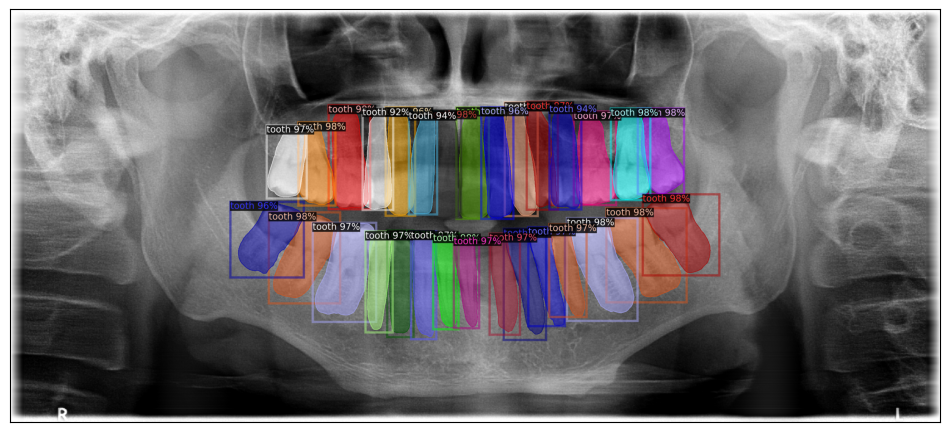


File 2 of 15: train_365.png with 31 instances.

The detection of the 31 segmentations took 0.834 seconds.



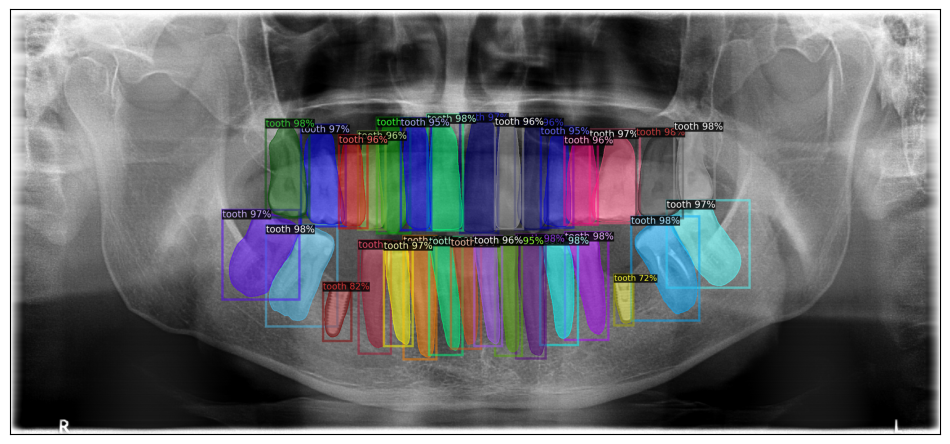


File 3 of 15: train_595.png with 30 instances.

The detection of the 30 segmentations took 0.567 seconds.



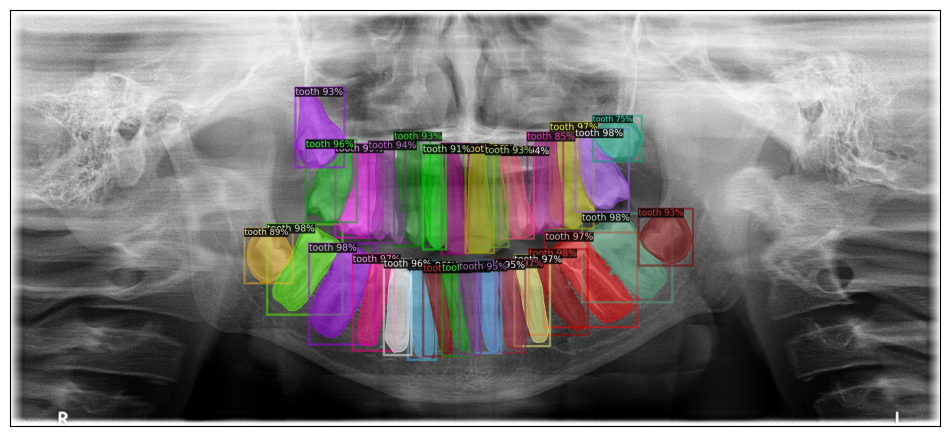

In [14]:
# Load the image
box_df_list = []
n_output_images = 15
image_number_list = files['image_number'].unique()[:n_output_images]

# Let's save the outputs
image_output_dir = os.path.join(os.environ.get('DATA'), 'output', 'segmentation', 'pano')
Path(image_output_dir).mkdir(exist_ok=True, parents=True)

for i, image_number in enumerate(image_number_list[:3]):
    start_time = time.time()
    image_df = files.loc[files['image_number'] == image_number]
    image_file = image_df['file_path'].values[0]
    image_name = image_df['file_name'].values[0]

    # Create a file name
    output_name = f'{os.path.splitext(image_name)[0]}_segmented.png'
    
    im = ImageData().load_image(image_file)
    # Instance segmentation predictions for this image
    pred = predictor(im)
    n_instances = len(pred.get('instances'))
    # Visualizer
    metadata = MetadataCatalog.get('dentex_test')
    vis = Visualizer(img_rgb=im, metadata=metadata, scale = 1.2)
    vis = vis.draw_instance_predictions(pred.get('instances').to('cpu'))
    fig, ax = show_image(vis.get_image(), figsize=(12, 6))
    dt = (time.time() - start_time)
    print()
    print(f'File {i + 1} of {len(image_number_list)}: {image_name} with {n_instances} instances.')
    print()
    print(f'The detection of the {n_instances} segmentations took {dt:.3f} seconds.')
    print()
    
    image_name = f'{os.path.splitext(image_name)[0]}_pred.png'
    plt.savefig(os.path.join(image_output_dir, image_name), bbox_inches='tight')
    plt.show()

### Run predictions for new images ###

2141


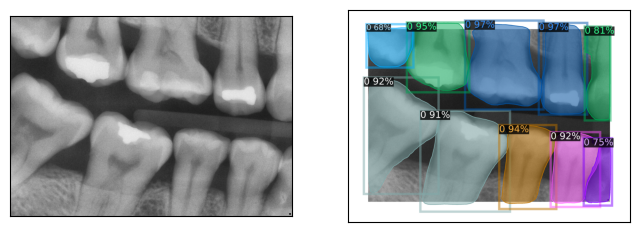

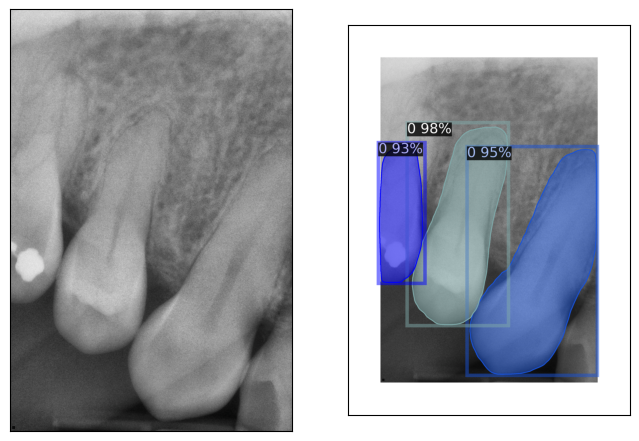

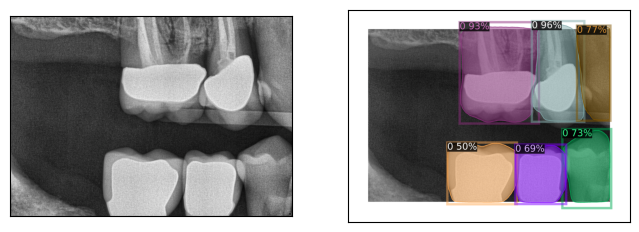

In [13]:
# Load a new images
pad_pixels = 2000
test_dir = os.path.join(os.environ.get('DATA'), 'dataset_object_240921')
test_file_list = glob.glob(os.path.join(test_dir, '*.png'))
print(len(test_file_list))

# Let's save the outputs
image_output_dir = os.path.join(os.environ.get('DATA'), 'output', 'segmentation', 'periapical')
Path(image_output_dir).mkdir(exist_ok=True, parents=True)

# Select a subset of images
n_images = 100
rng = np.random.default_rng(seed=234)
test_files = rng.choice(test_file_list, size=n_images, replace=False)

for f, test_file in enumerate(test_files[:3]):
    # File name for the output
    image_name = f'{os.path.splitext(os.path.basename(test_file))[0]}_segmented.png'
    # Load the image
    im = ImageData().load_image(test_file)
    im_height, im_width = im.shape[:2]
    # Add padding (we need it because the panoramic images are so much larger)
    im_padded = ImageData().np_square_pad(im, pad_pixels=pad_pixels, pad_number=255)
    # Convert to RGB
    im_padded = ImageData().np2color(im_padded)
    im = ImageData().np2color(im)
    # Contrast enhancement
    im_padded = ImageData().hist_eq(im_padded)
    im = ImageData().hist_eq(im)
    
    # Inference
    outputs = predictor(im_padded)
    v = Visualizer(im_padded[:, :, ::-1], 
                   MetadataCatalog.get(cfg.DATASETS.TRAIN[0]), scale=1)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    im_out_padded = out.get_image()[:, :, ::-1]

    # Remove the padding
    offset = 200
    box = [pad_pixels - offset, pad_pixels - offset, im_width + 2 * offset, im_height + 2 * offset]
    im_out = crop_image(im_out_padded, box)
    
    fig, ax = plt.subplots(figsize=(8, 8), nrows=1, ncols=2)
    ax[0].imshow(im)
    ax[1].imshow(im_out)
    ax[0].set(xticks=[], yticks=[])
    ax[1].set(xticks=[], yticks=[])
    plt.savefig(os.path.join(image_output_dir, image_name), bbox_inches='tight')
    plt.show()